In [ ]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import sys, os, time

sys.path.append('packages')

import crydberg_v3_0_0 as rd

# Generating fresh ensemble

In [ ]:
N = 10
n_samples_parallel = 5000
n_samples_thermal = 2
n_samples = n_samples_parallel*n_samples_thermal
K = 0
S = 1
precession = 0

# making fresh directory
dir_sys = f'data/N{N}_K{K}_thermalOnly_forActualOverlap_S{S}'
os.makedirs(dir_sys, exist_ok=True)

systems = rd.MagneticSystem(N, n_samples, K=K) # generating system
systems.align_m() # randomizing initial spin config. m0

# setting Js of thermal samples batches with one J
J_toSet = []
for J in systems.J[:n_samples_parallel]:
    J_toSet.append(cp.broadcast_to(J, (n_samples_thermal, N, N)))
J_toSet = cp.array(J_toSet)
J_toSet = J_toSet.reshape(n_samples, N, N)
systems.J = J_toSet
del J_toSet # deleting buffer

# zeroing Js
# systems.J = np.zeros_like(systems.J) #################

In [13]:
np.save(f'{dir_sys}/m0.npy', systems.m.get()) # saving m0
np.save(f'{dir_sys}/J.npy', systems.J.get()) # saving coupling matrices

# Running dynamics

In [14]:
dt = 0.01
n_steps_burn = 20000
n_recordedPoints = 100
recordedSteps_gap = 100
n_steps_history = n_recordedPoints*recordedSteps_gap
T_vals = np.linspace(0, 1, 11)
np.save(f'{dir_sys}/T_vals.npy', T_vals)

start_index = 0
start_time = time.time()
# running for each temperature
for T_idx, T in enumerate(T_vals):
    if T_idx >= start_index:
        # burning-in system
        for i in range(n_steps_burn):
            systems.LLG_1stepSIB(dt, alpha=1, precession=precession, T=T)
            print(f'\rBurn-in Progress: {np.round(100*i/n_steps_burn, 2)}%', end='')
        
        # storing data
        history = []
        for i in range(n_steps_history):
            if (i % recordedSteps_gap == 0): history.append(systems.m)
            systems.LLG_1stepSIB(dt, alpha=1, precession=precession, T=T)
            print(f'\rRecording Progress: {np.round(100*i/n_steps_history, 2)}%', end='')
        history = cp.array(history).reshape(n_recordedPoints, n_samples_parallel, n_samples_thermal, N, 3)
        np.save(f'{dir_sys}/history_T{T_idx}.npy', history.get())
        print(f'\r{T_idx + 1}/{T_vals.size} Done.                   ')
duration = time.time() - start_time
print(duration)

1/11 Done.                   
2/11 Done.                   
3/11 Done.                   
4/11 Done.                   
5/11 Done.                   
6/11 Done.                   
7/11 Done.                   
8/11 Done.                   
9/11 Done.                   
10/11 Done.                   
11/11 Done.                   
2145.035263299942


# Continuing run

In [ ]:
N = 10
n_samples_parallel = 10000
n_samples_thermal = 1
n_samples = n_samples_parallel*n_samples_thermal
K = 1

dt = 0.01
n_steps_burn = 20000
n_recordedPoints = 100
recordedSteps_gap = 100
n_steps_history = n_recordedPoints*recordedSteps_gap
T_vals = np.linspace(1, 2, 5)

# making fresh directory
dir_src = f'data/N{N}_K{K}_highTemp_moreDisorder_S1'
dir_sys = f'data/N{N}_K{K}_highTemp_moreDisorder_S2'
os.makedirs(dir_sys, exist_ok=True)

# generating ensemble
systems = rd.MagneticSystem(N, n_samples, K=K)

# setting J from previous run
systems.J = cp.load(f'{dir_src}/J.npy')

start_index = 0
start_time = time.time()
# running for each temperature
for T_idx, T in enumerate(T_vals):
    if T_idx >= start_index:
        # setting spin configuration from last step of previous run
        history = cp.load(f'{dir_src}/history_T{T_idx}.npy')[-1,:,:,:,:]
        systems.m = history.reshape(history.shape[0]*history.shape[1], *history.shape[-2:])

        # burning-in system
        for i in range(n_steps_burn):
            systems.LLG_1stepSIB(dt, alpha=1, precession=0, T=T)
            print(f'\rBurn-in Progress: {np.round(100*i/n_steps_burn, 2)}%', end='')
        
        # storing data
        history = []
        for i in range(n_steps_history):
            if (i % recordedSteps_gap == 0): history.append(systems.m)
            systems.LLG_1stepSIB(dt, alpha=1, precession=0, T=T)
            print(f'\rRecording Progress: {np.round(100*i/n_steps_history, 2)}%', end='')
        history = cp.array(history).reshape(n_recordedPoints, n_samples_parallel, n_samples_thermal, N, 3)
        np.save(f'{dir_sys}/history_T{T_idx}.npy', history.get())
        print(f'\r{T_idx + 1}/{T_vals.size} Done.                   ')
duration = time.time() - start_time
print(duration)

1/5 Done.     ress: 99.99%
2/5 Done.     ress: 99.99%
3/5 Done.     ress: 99.99%
4/5 Done.     ress: 99.99%
5/5 Done.     ress: 99.99%
974.8307166099548


# Edwards-Anderson parameter

In [97]:
dir_sys = 'data/N30_K1_S1'
T_vals = np.load(f'{dir_sys}/T_vals.npy')

In [98]:
EA = []
for T_idx, T in enumerate(T_vals):
    history = np.load(f'{dir_sys}/history_T{T_idx}.npy')
    EA_T = np.mean(np.mean(history, axis=0)**2, axis=(0,1,2))
    EA.append(EA_T)
EA = np.array(EA)
np.save(f'{dir_sys}/EA.npy', EA)

EA2 = []
for T_idx, T in enumerate(T_vals):
    history = np.load(f'{dir_sys}/history_T{T_idx}.npy')
    EA2_T = np.mean(np.mean(history, axis=0)**4, axis=(0,1,2))
    EA2.append(EA2_T)
EA2 = np.array(EA2)
np.save(f'{dir_sys}/EA2.npy', EA2)

In [99]:
U = 1 - EA2/EA**2/3
np.save(f'{dir_sys}/U.npy', U)

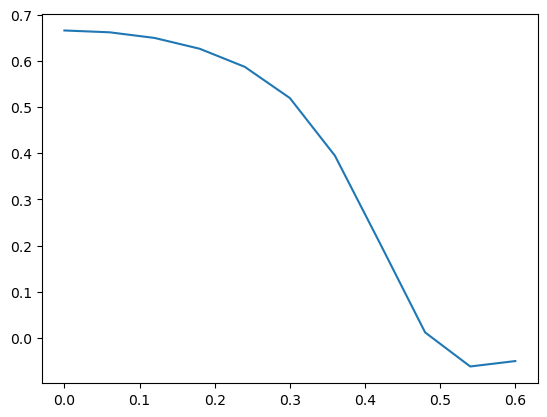

In [100]:
plt.plot(T_vals, U[:,2])

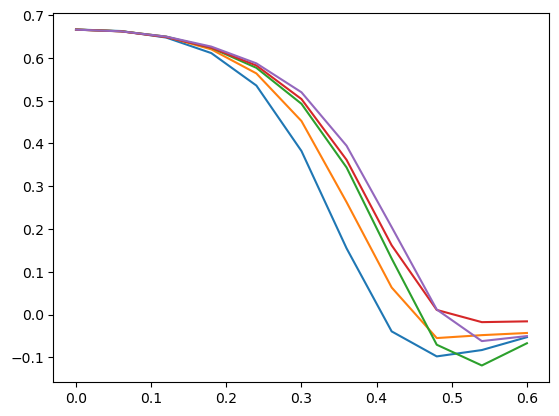

In [101]:
plt.plot(T_vals, np.load('data/N10_K1_S1/U.npy')[:,2])
plt.plot(T_vals, np.load('data/N15_K1_S1/U.npy')[:,2])
plt.plot(T_vals, np.load('data/N20_K1_S1/U.npy')[:,2])
plt.plot(T_vals, np.load('data/N25_K1_S1/U.npy')[:,2])
plt.plot(T_vals, np.load('data/N30_K1_S1/U.npy')[:,2])

# Correlation

In [ ]:
N = 10
K = 1
dir_initSrc = f'data/N{N}_K{K}'
dir_sys     = f'data/N{N}_K{K}_S2'

m0 = np.load(f'{dir_initSrc}/m0_N{N}_K{K}.npy')
history = np.load(f'{dir_sys}/history_N{N}_K{K}_T1.npy')
history_shape = history.shape
history = history.reshape(history_shape[1]*history_shape[2], history_shape[3], history_shape[4])

In [11]:
corr = np.mean(m0*history, axis=(0,1))

In [12]:
corr

array([-0.00138319,  0.00071676,  0.01443364])

# Scratch

In [135]:
history = np.load('data/N10_K0_thermalOnly_S1/history_T4.npy')

In [106]:
history.shape

(100, 100, 100, 10, 3)

In [ ]:
history = history.reshape(history.shape[0]*history.shape[1]*history.shape[2]*history.shape[3], history.shape[4])

In [136]:
history_timeMean = np.mean(history, axis=0)
history_timeMean = history_timeMean.reshape(history_timeMean.shape[0]*history_timeMean.shape[1]*history_timeMean.shape[2], history_timeMean.shape[3])
sz_timeMean = history_timeMean[:,2]

In [123]:
history_timeMean.shape

(100, 100, 10, 3)

In [108]:
sz = history[:,2]

<BarContainer object of 100 artists>

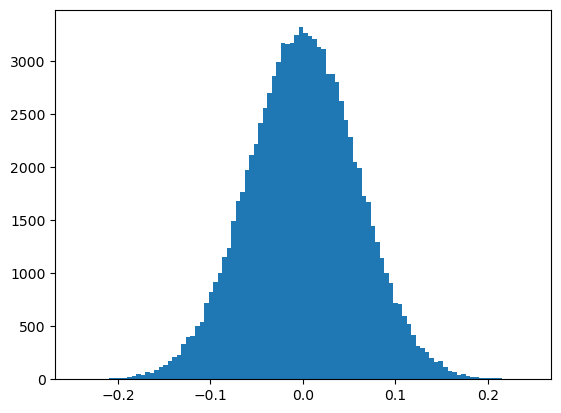

In [137]:
plt.hist(sz_timeMean, bins=100)[2]

In [138]:
np.mean(sz_timeMean**2), np.var(sz_timeMean**2)

(np.float64(0.003488321606120198), np.float64(2.4317806951655014e-05))

In [139]:
np.mean(sz_timeMean**4), np.var(sz_timeMean**4)

(np.float64(3.648619457938e-05), np.float64(1.3902729869577237e-08))

In [140]:
np.mean(sz_timeMean**2)**2*3

np.float64(3.650516288317499e-05)

<BarContainer object of 50 artists>

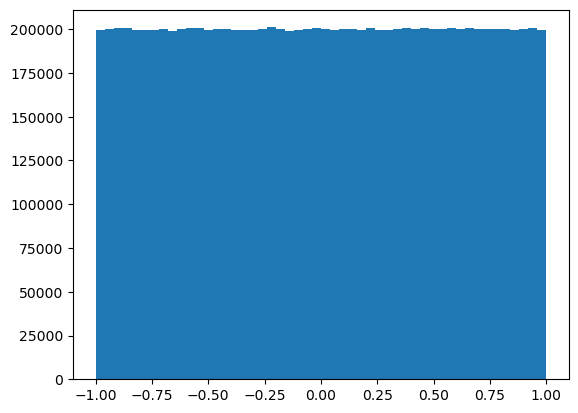

In [73]:
plt.hist(sz, bins=50)[2]

<BarContainer object of 50 artists>

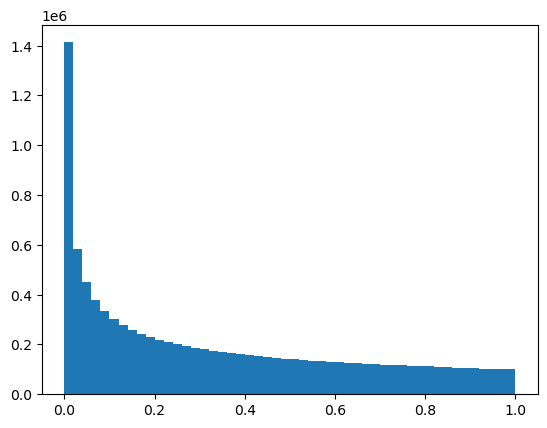